# Taller 6: Morfología matemática

### Sebastián Palma

### David Tobón Molina

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

## 1. Operadores de dilatación y erosión

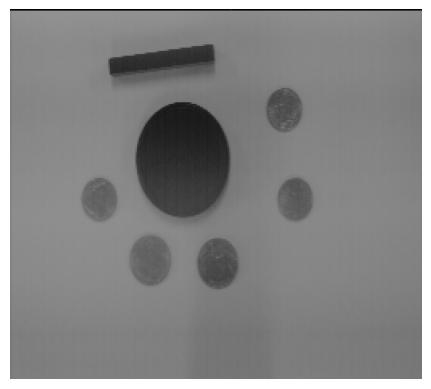

In [ ]:
morpho_imagen = cv2.imread('images/MORPHO.png', cv2.IMREAD_GRAYSCALE)

plt.imshow(morpho_imagen, cmap='gray', vmin=0, vmax=255)
plt.axis('off')
plt.show()

### 1.3 Haga una umbralización de esta imagen, para obtener objetos negros sobre fondo blanco (umbral alrededor de 115).

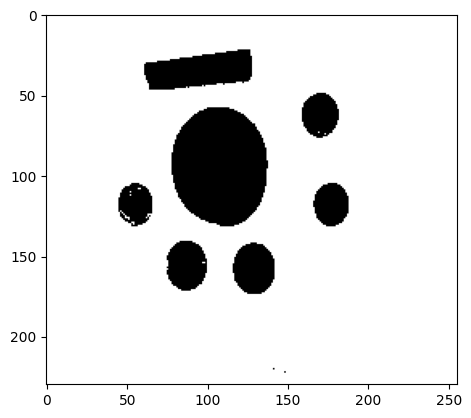

In [ ]:
thres_value, morpho_umbralizacion = cv2.threshold(morpho_imagen, 114, 255, cv2.THRESH_BINARY)

plt.imshow(morpho_umbralizacion, cmap='gray', vmin=0, vmax=255)
plt.show()

### 1.4 Sobre la imagen binaria efectúe una dilatación con un elemento estructurante o máscara cuadrada de 29x29. ¿Qué obtiene como resultado?

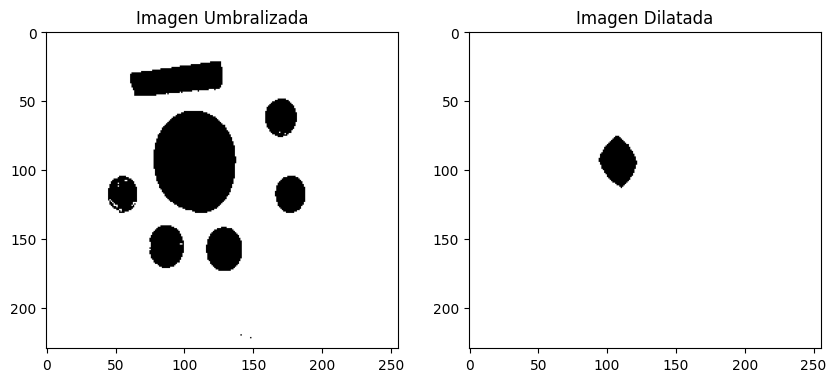

In [18]:
from skimage.morphology import dilation

elemento_estructural = np.ones((29, 29), np.uint8)
morpho_dilatada = dilation(morpho_umbralizacion, footprint = elemento_estructural)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title("Imagen Umbralizada")
plt.imshow(morpho_umbralizacion, cmap="gray", vmin=0, vmax=255)
plt.subplot(1, 2, 2)
plt.title("Imagen Dilatada")
plt.imshow(morpho_dilatada, cmap="gray", vmin=0, vmax=255)
plt.show()

Al aplicar la dilatación con una máscara cuadrada de 29x29 sobre la imagen umbralizada, el fondo blanco se expande y los objetos negros se reducen considerablemente, por lo que desaparecen los más pequeños y solo permanece el objeto de mayor tamaño aunque en menor proporcion.

### 1.5 Sobre la imagen resultante, haga una erosión con la misma máscara. ¿Cómo es el objeto obtenido con respecto al original?

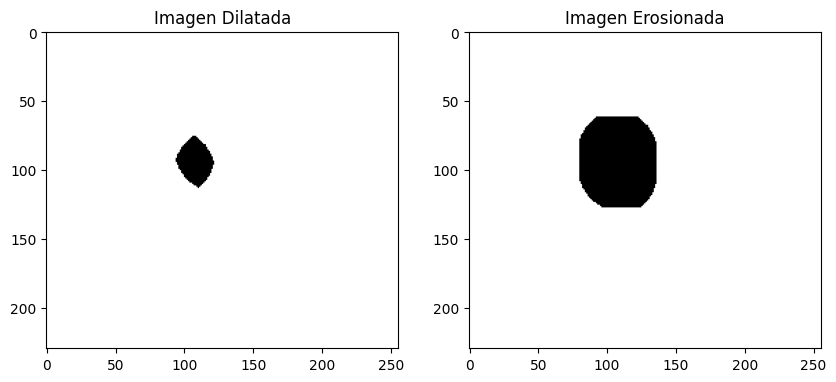

In [13]:
from skimage.morphology import erosion

morpho_erosionada = erosion(morpho_dilatada, footprint=elemento_estructural)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title("Imagen Dilatada")
plt.imshow(morpho_dilatada, cmap="gray", vmin=0, vmax=255)
plt.subplot(1, 2, 2)
plt.title("Imagen Erosionada")
plt.imshow(morpho_erosionada, cmap="gray", vmin=0, vmax=255)
plt.show()

Al erosionar la imagen dilatada con la misma máscara de 29x29, el objeto negro que permanecía vuelve a crecer y recupera una forma similar a la del objeto original más grande, aunque no queda muy similar. En comparación con el original, se observa más regular, más limpio y sin los objetos pequeños que fueron eliminados en el paso anterior.

### 1.6 Sobre la imagen resultado del punto anterior, haga una erosión con una máscara en cruz, de tamaño 11x11. Las máscaras en cruz deben crearse generando una matriz de nxn (tamaño deseado) y colocando 1’ s en la cruz. Los demás elementos se deben dejar vacíos (SIN CEROS).

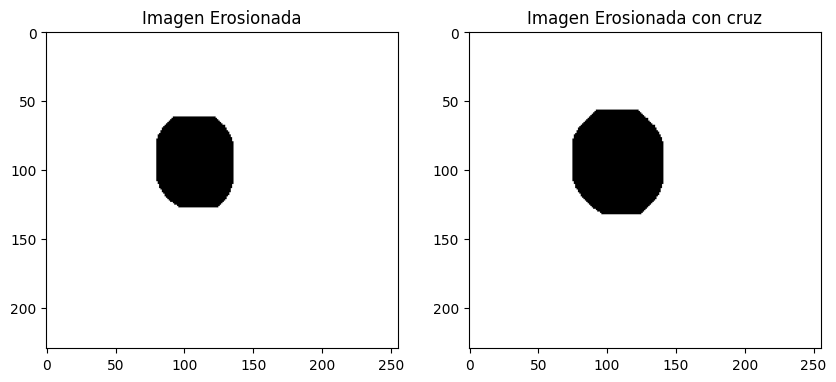

In [ ]:
elemento_estructural_1 = np.zeros((11, 11), np.uint8)
elemento_estructural_1[5, :] = 1
elemento_estructural_1[:, 5] = 1

morpho_erosionada_2 = erosion(morpho_erosionada, footprint=elemento_estructural_1)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title("Imagen Erosionada")
plt.imshow(morpho_erosionada, cmap="gray", vmin=0, vmax=255)
plt.subplot(1, 2, 2)
plt.title("Imagen Erosionada con cruz")
plt.imshow(morpho_erosionada_2, cmap="gray", vmin=0, vmax=255)
plt.show()

### 1.7 Calcule el máximo entre esta última imagen y la imagen original umbralizada. ¿Cómo es el resultado obtenido?

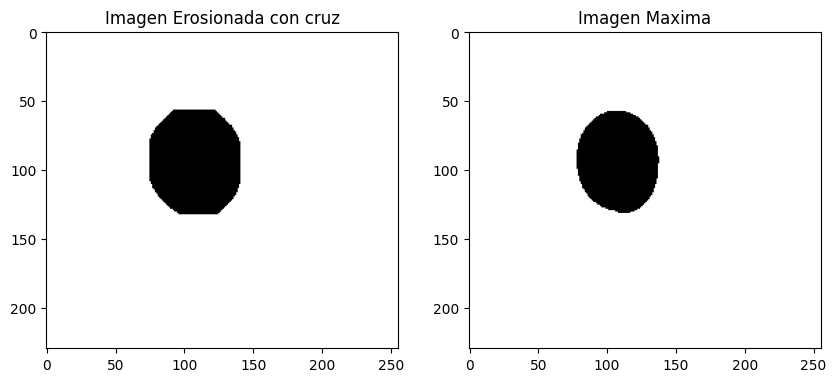

In [16]:
morpho_maximo = np.maximum(morpho_umbralizacion, morpho_erosionada_2)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title("Imagen Erosionada con cruz")
plt.imshow(morpho_erosionada_2, cmap="gray", vmin=0, vmax=255)
plt.subplot(1, 2, 2)
plt.title("Imagen Maxima")
plt.imshow(morpho_maximo, cmap="gray", vmin=0, vmax=255)
plt.show()

Al calcular el máximo entre la imagen erosionada con cruz y la imagen original umbralizada, se obtiene un objeto más parecido al original principal, con una forma más redondeada. El resultado mantiene el objeto más grande y recupera parte de su apariencia original, mientras los objetos pequeños siguen sin aparecer.

### 1.8 Repita las operaciones 1 a 4, trabajando directamente con la imagen original no umbralizada (en niveles de gris).

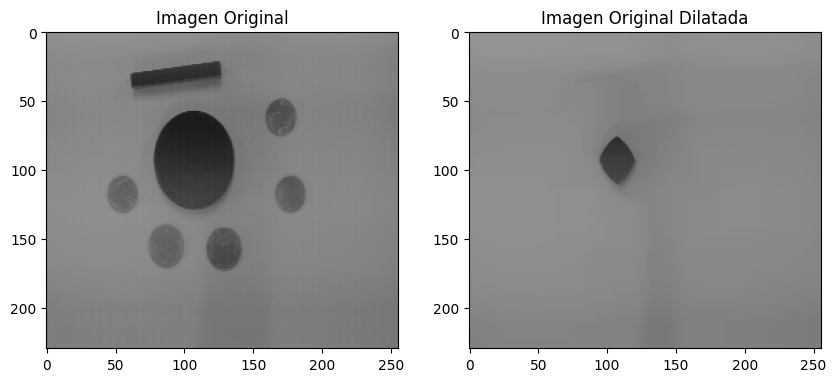

In [20]:
morpho_original_dilata = dilation(morpho_imagen, footprint=elemento_estructural)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title("Imagen Original")
plt.imshow(morpho_imagen, cmap="gray", vmin=0, vmax=255)
plt.subplot(1, 2, 2)
plt.title("Imagen Original Dilatada")
plt.imshow(morpho_original_dilata, cmap="gray", vmin=0, vmax=255)
plt.show()

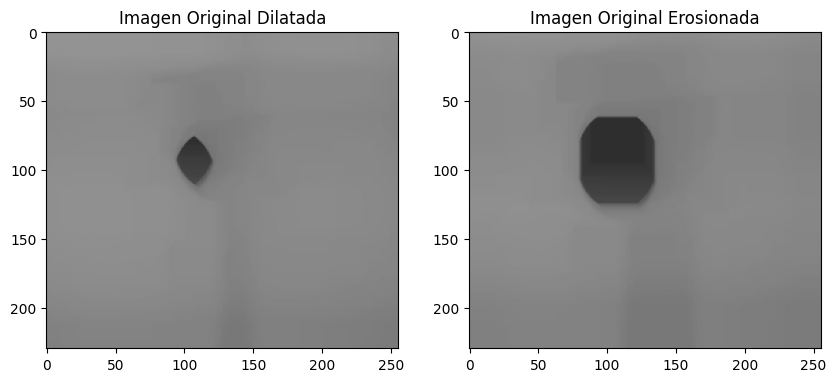

In [21]:
morpho_original_erosionada = erosion(morpho_original_dilata, footprint=elemento_estructural)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title("Imagen Original Dilatada")
plt.imshow(morpho_original_dilata, cmap="gray", vmin=0, vmax=255)
plt.subplot(1, 2, 2)
plt.title("Imagen Original Erosionada")
plt.imshow(morpho_original_erosionada, cmap="gray", vmin=0, vmax=255)
plt.show()

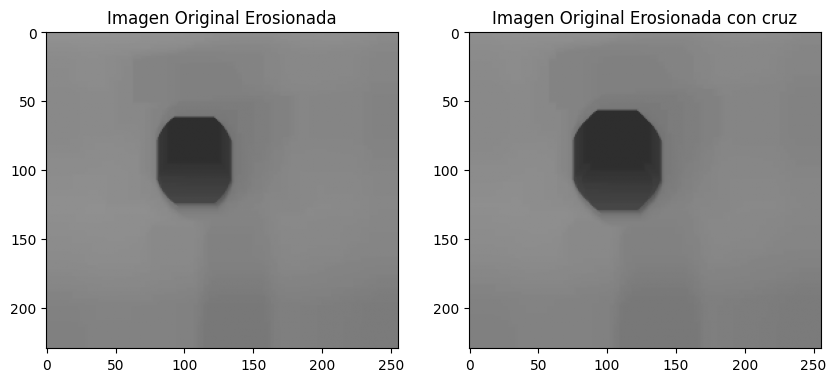

In [22]:
elemento_estructural_1 = np.zeros((11, 11), np.uint8)
elemento_estructural_1[5, :] = 1
elemento_estructural_1[:, 5] = 1

morpho_original_erosionada_2 = erosion(morpho_original_erosionada, footprint=elemento_estructural_1)
1
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title("Imagen Original Erosionada")
plt.imshow(morpho_original_erosionada, cmap="gray", vmin=0, vmax=255)
plt.subplot(1, 2, 2)
plt.title("Imagen Original Erosionada con cruz")
plt.imshow(morpho_original_erosionada_2, cmap="gray", vmin=0, vmax=255)
plt.show()

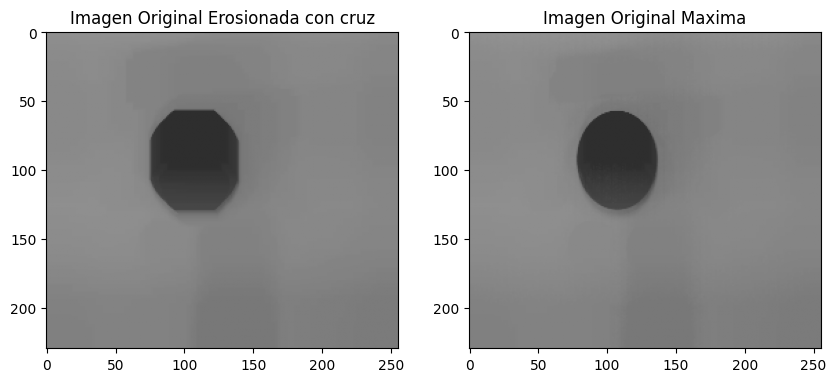

In [23]:
morpho_original_maximo = np.maximum(morpho_imagen, morpho_original_erosionada_2)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title("Imagen Original Erosionada con cruz")
plt.imshow(morpho_original_erosionada_2, cmap="gray", vmin=0, vmax=255)
plt.subplot(1, 2, 2)
plt.title("Imagen Original Maxima")
plt.imshow(morpho_original_maximo, cmap="gray", vmin=0, vmax=255)
plt.show()

### 1.9 ¿Cómo funcionan las operaciones de erosión y de dilatación en imágenes en niveles de gris?

En imágenes en niveles de gris, la dilatación y la erosión no trabajan únicamente con píxeles blancos y negros, sino con los valores de intensidad que hay dentro de una vecindad definida por el elemento estructurante. La dilatación asigna a cada píxel el valor máximo encontrado en esa vecindad, mientras que la erosión asigna el valor mínimo. Por esta razón, la dilatación tiende a expandir las regiones más claras y a disminuir la presencia de zonas oscuras pequeñas, mientras que la erosión produce el efecto contrario, ya que expande visualmente las zonas más oscuras y reduce las claras. Además, estas operaciones no solo modifican el tamaño aparente de los objetos, sino también sus bordes, el contraste local y la suavidad de las transiciones entre regiones.

### 1.10 ¿Cómo es el resultado obtenido sobre la imagen en niveles de gris, comparado con el resultado sobre la imagen binaria?

Al comparar los resultados obtenidos en la imagen en niveles de gris con los de la imagen binaria, se nota que el procesamiento en grises conserva mucha más información de la imagen original. Mientras que en la imagen binaria cada píxel se reduce a solo dos valores posibles, lo que simplifica mucho la escena y elimina detalles como variaciones internas de intensidad, sombras y transiciones suaves en los bordes. En la imagen en niveles de gris todavía se mantienen esos cambios graduales de tono, por lo que el objeto principal sigue siendo visible y los objetos pequeños pueden atenuarse o desaparecer sin que la imagen pierda por completo su apariencia original. Por eso, el resultado en binario se ve más brusco y más rígido, mientras que en niveles de gris se percibe más natural, más continuo y visualmente más cercano a la imagen inicial.

## 2. Gradiente morfológico

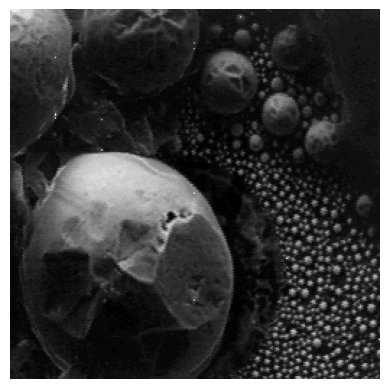

In [24]:
meb_imagen = cv2.imread('images/MEB.png', cv2.IMREAD_GRAYSCALE)

plt.imshow(meb_imagen, cmap='gray', vmin=0, vmax=255)
plt.axis('off')
plt.show()

### 2.3 Utilizando una máscara cuadrada de 3x3, calcule el gradiente morfológico de esta imagen.

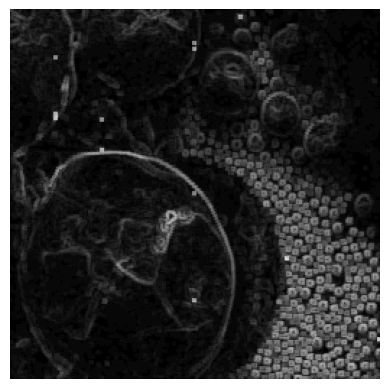

In [25]:
from scipy.ndimage import morphological_gradient

meb_gradiente = morphological_gradient(meb_imagen, size=(3, 3))

plt.imshow(meb_gradiente, cmap='gray', vmin=0, vmax=255)
plt.axis('off')
plt.show()

### 2.4 Genere la imagen de la norma del gradiente de la imagen meb.png con el operador de Sobel (ver Taller 3). Compare los resultados obtenidos (gradiente morfológico vs. norma del gradiente con Sobel). Puede efectuar una expansión del contraste sobre las dos imágenes obtenidas para visualizar mejor el resultado.

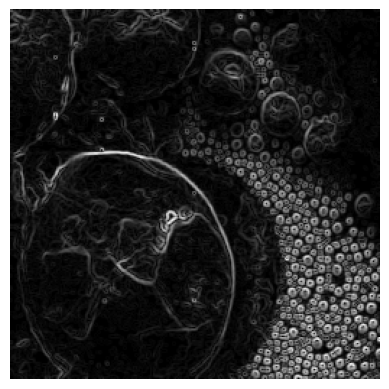

In [27]:
from skimage.filters import sobel

meb_sobel = sobel(meb_imagen)

plt.imshow(meb_sobel, cmap='gray')
plt.axis('off')
plt.show()

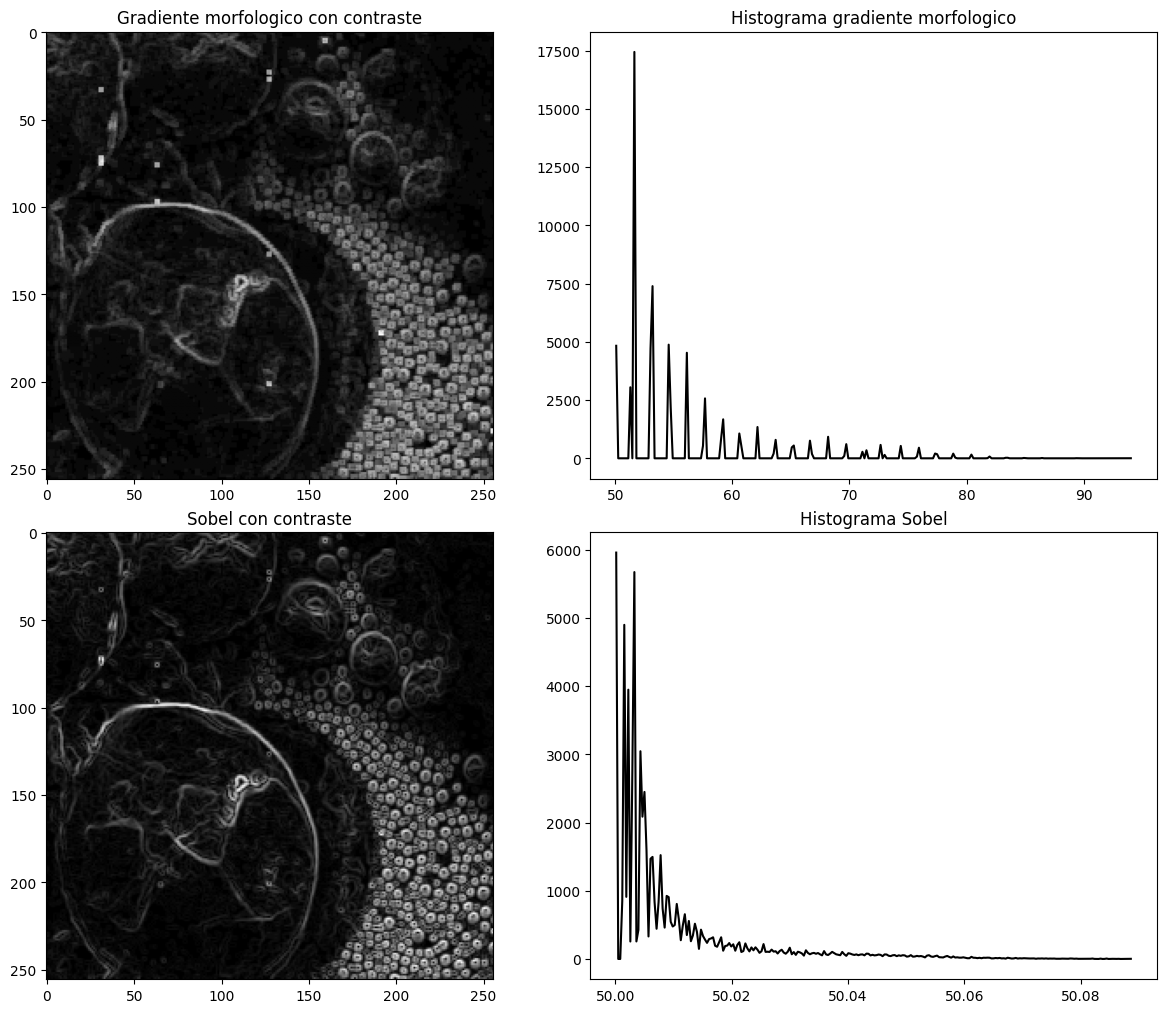

In [47]:
from skimage import exposure

expansion_gradiente = exposure.rescale_intensity(meb_gradiente, in_range=(0,255), out_range=(50, 100))
expansion_sobel = exposure.rescale_intensity(meb_sobel, in_range=(0,255), out_range=(50, 100))
histograma_gradiente = exposure.histogram(expansion_gradiente)
histograma_sobel = exposure.histogram(expansion_sobel)

plt.figure(figsize=(12, 10))
plt.subplot(2, 2, 1)
plt.title("Gradiente morfologico con contraste")
plt.imshow(expansion_gradiente, cmap='gray')
plt.subplot(2, 2, 2)
plt.title("Histograma gradiente morfologico")
plt.plot(histograma_gradiente[1], histograma_gradiente[0], color='black')
plt.tight_layout()
plt.subplot(2, 2, 3)
plt.title("Sobel con contraste")
plt.imshow(expansion_sobel, cmap='gray')
plt.subplot(2, 2, 4)
plt.title("Histograma Sobel")
plt.plot(histograma_sobel[1], histograma_sobel[0], color='black')
plt.subplots_adjust(hspace=0.12)
plt.show()

Al aplicar la expansión de contraste, la comparación entre ambas imágenes se aprecia mucho mejor, puesto que los bordes resaltan con más claridad. Se puede observar cómo el gradiente morfológico muestra contornos más gruesos y marcados, lo que facilita la identificación de los objetos. Por otro lado, el operador de Sobel produce bordes más finos y detallados, por lo que representa mejor las variaciones locales de intensidad.

### 2.5 Repita la operación 3 empleando la misma máscara, pero SIN utilizar el operador de gradiente morfológico (créelo con los operadores de dilatación y de erosión, precedidos por un filtrado mediano). ¿Cómo es el resultado obtenido?

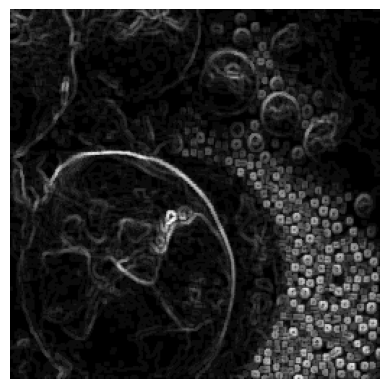

In [75]:
from skimage.filters.rank import median
from skimage.morphology import footprint_rectangle, erosion as morf_erosion

filtro = median(meb_imagen, footprint=footprint_rectangle((3, 3)))
erosionada = morf_erosion(filtro, footprint=footprint_rectangle((3, 3)))
dilatada = dilation(filtro, footprint=footprint_rectangle((3, 3)))
gradiente = dilatada - erosionada

plt.imshow(gradiente, cmap='gray')
plt.axis('off')
plt.show()

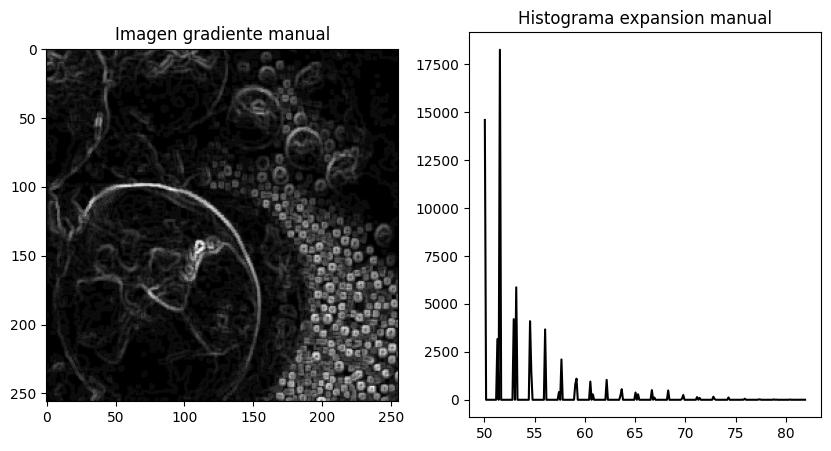

In [76]:
expansion_manual = exposure.rescale_intensity(gradiente, in_range=(0,255), out_range=(50, 100))
histograma_manual = exposure.histogram(expansion_manual)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title("Imagen gradiente manual")
plt.imshow(expansion_manual, cmap="gray")
plt.subplot(1, 2, 2)
plt.title("Histograma expansion manual")
plt.plot(histograma_manual[1], histograma_manual[0], color='black')
plt.show()

Al construir el gradiente manualmente, aplicando primero un filtro mediano y luego restando la erosión de la dilatación, se obtiene un resultado muy similar al gradiente morfológico calculado directamente, ya que en ambos casos se resaltan los bordes principales de la imagen. Sin embargo, el uso previo del filtro mediano hace que el resultado manual se vea un poco más limpio y estable, porque reduce pequeñas variaciones y ruido antes de aplicar las operaciones morfológicas.

## 3. Operadores de apertura y cierre

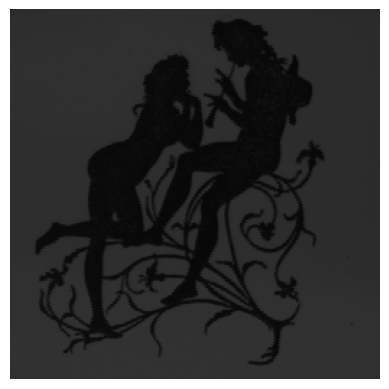

In [77]:
amour_imagen = cv2.imread('images/AMOUR.png', cv2.IMREAD_GRAYSCALE)

plt.imshow(amour_imagen, cmap='gray', vmin=0, vmax=255)
plt.axis('off')
plt.show()

### 3.3 Realice la operación de apertura usando una máscara cuadrada de tamaño 5x5. ¿Qué partes fueron suprimidas? 

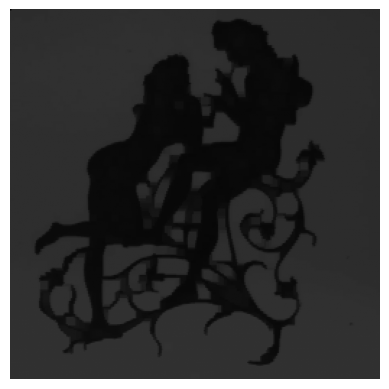

In [80]:
from skimage.morphology import opening

amour_apertura = opening(amour_imagen, footprint=footprint_rectangle((5, 5)))

plt.imshow(amour_apertura, cmap='gray', vmin=0, vmax=255)
plt.axis('off')
plt.show()

Al aplicar la apertura con una máscara cuadrada de 5x5, se suprimieron las terminaciones finas y pequeños salientes de los detalles delgados, mientras que las siluetas principales se conservaron.

### 3.4 Retome la imagen original, y aplique una umbralización para binarizarla (umbral = 35).

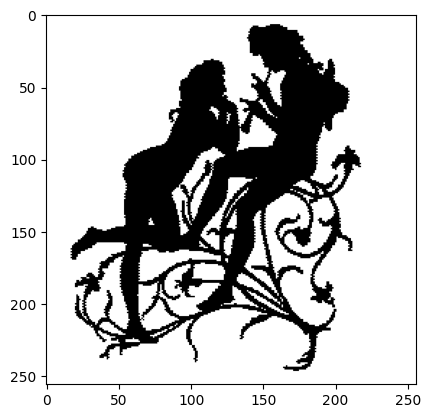

In [82]:
thres_value, amour_umbralizacion = cv2.threshold(amour_imagen, 35, 255, cv2.THRESH_BINARY)

plt.imshow(amour_umbralizacion, cmap='gray', vmin=0, vmax=255)
plt.show()

### 3.5 Realice el cierre de la imagen. Para esto, efectúe 4 cierres aplicando sucesivamente las 4 máscaras lineales simétricas de tamaño 1x3 (en este orden: las dos diagonales ( / y después \ ), horizontal ( - ) y vertical ( | )). Las máscaras diagonales (u oblicuas) deben crearse generando una matriz de 3x3 y colocando 1’ s sobre las diagonales. Los demás elementos se deben dejar vacíos (SIN CEROS). La máscara horizontal debe crearse generando una matriz de 3x1 llena de 1’s. La máscara vertical debe crearse generando una matriz de 1x3 llena de 1’s.

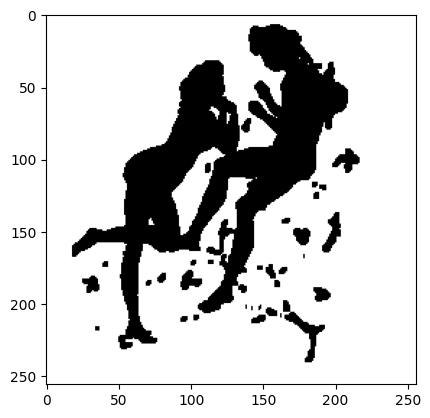

In [83]:
from skimage.morphology import closing

diagonal_1 = np.eye(3, dtype=np.uint8)
diagonal_2 = np.fliplr(np.eye(3, dtype=np.uint8))
horizontal = np.ones((1, 3), dtype=np.uint8)
vertical = np.ones((3, 1), dtype=np.uint8)

amour_cierre_diagonal_1 = closing(amour_umbralizacion, footprint=diagonal_1)
amour_cierre_diagonal_2 = closing(amour_cierre_diagonal_1, footprint=diagonal_2)
amour_cierre_horizontal = closing(amour_cierre_diagonal_2, footprint=horizontal)
amour_cierre_vertical = closing(amour_cierre_horizontal, footprint=vertical)

plt.imshow(amour_cierre_vertical, cmap='gray', vmin=0, vmax=255)
plt.show()

### 3.6 ¿Cuál es el efecto obtenido?

Se obtuvo el cierre de pequeños huecos y discontinuidades en la imagen binaria, haciendo que las siluetas principales quedaran más continuas y compactas. Además, varias regiones cercanas se conectaron mejor según la orientación de las máscaras aplicadas, aunque todavía permanecen algunos fragmentos pequeños aislados.

### 3.7 Tome el negativo de la imagen resultado, de forma tal que las figuras se vuelvan blancas.

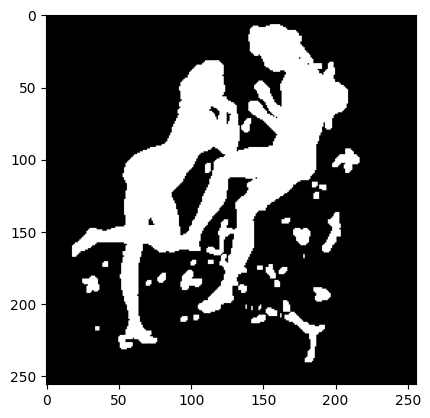

In [87]:
amour_negativo = cv2.bitwise_not(amour_cierre_vertical)

plt.imshow(amour_negativo, cmap='gray', vmin=0, vmax=255)
plt.show()

### 3.8 Seleccione el componente conexo más grande. ¿Cuál es el resultado?

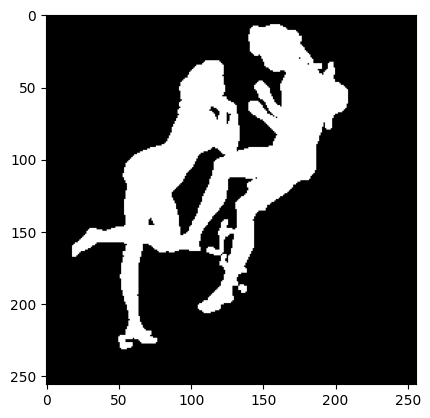

In [91]:
from skimage.measure import label, regionprops

componentes = label(amour_negativo, background=0, connectivity=2)
regiones = regionprops(componentes)
mayor_region = max(regiones, key=lambda x: x.area)
amour_componenten_conexo = np.zeros_like(componentes, dtype=np.uint8)
amour_componenten_conexo[componentes == mayor_region.label] = 255

plt.imshow(amour_componenten_conexo, cmap='gray')
plt.show()

Al seleccionar el componente conexo más grande, se conserva únicamente la figura principal de la imagen y se eliminan los fragmentos pequeños aislados. El negativo sirve para convertir las figuras en regiones blancas sobre fondo negro, lo que facilita la detección y el etiquetado de los componentes conectados, permitiendo aislar con mayor facilidad la estructura dominante.

## 4. Etiquetado de objetos

## 5. Imagen de distancia

## 6. Esqueleto y adelgazamiento de una imagen

## 7. Ejercicio de síntesis taller 6